This notebook shows mismatch between lensed waveforms generated with normal lensing effects (i.e., time delay and effective distance change) and ones generated with additional second order corrections (angular changes and Doppler shift).

In [2]:
import os
import sys
import copy
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.new_signal import NewGWSignal
from gwfast.AGN_lensed_signal import AGNLensedGWSignal
import gwfast.network as network
import gwfast.lensing_utils as lutils

In [3]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_BBH = NewGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_BBH = NewGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_BBH = NewGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_BBH = network.DetNet({'H1': H1_BBH, 'L1': L1_BBH, 'V1': V1_BBH})

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [4]:
# Define a benchmark event
n = 20
shape = (n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 'tcoal':np.full(shape, 0), 'Phicoal':np.full(shape, 2), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 'chi1x':np.full(shape, 0), 'chi2x':np.full(shape, 0), 'chi1y':np.full(shape, 0), 'chi2y':np.full(shape, 0), 
    'LambdaTilde':np.full(shape, 0), 'deltaLambda':np.full(shape, 0), 'ecc':np.full(shape, 0), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5)
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Compute benchmark SNR
event = {key: values[0, 0] for key, values in events.items()}
HLV_BBH_SNR = HLV_BBH.SNR(event)
HLV_AGN_SNR = HLV_AGN.SNR(event)
print('SNR without lensing:', HLV_BBH_SNR, "\nSNR with lensing:", HLV_AGN_SNR)

SNR without lensing: 25.698484636691628 
SNR with lensing: 28.97689811223678


In [5]:
# Waveform metadata
sampling_frequency = 1024.  # Hz
minimum_frequency = 10.  # Hz
maximum_frequency = sampling_frequency / 2
N_freq_bins = 1000

# Make frequency grid
minimum_frequency_array = np.full(shape, minimum_frequency)
maximum_frequency_array = np.full(shape, maximum_frequency)
freq_grid = np.geomspace(minimum_frequency_array, maximum_frequency_array, N_freq_bins)

# Interpolate PSD
freq_array = np.geomspace(minimum_frequency, maximum_frequency, N_freq_bins)
psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)
psd_interp_grid = np.reshape(np.repeat(psd_interp, n**2), (-1, n, n))

In [6]:
# Mismatch definition
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapz(integrand, frequencies, axis=0))

def mismatch(frequencies, h1, h2, psd):
    return inner_product(frequencies, h1-h2, h1-h2, psd) / (2 * (inner_product(frequencies, h1, h1, psd) + inner_product(frequencies, h2, h2, psd)))

In [7]:
# Sample parameter space
R_orbit_array = np.geomspace(20, 1000, n)
Mc_array = np.linspace(10, 100, n)
M_lz_array = np.geomspace(5e3, 5e6, n)
src_pos_array = np.linspace(0.05, 0.5, n)

In [8]:
# Prepare injections
R_orbit_mesh, Mc_mesh = np.meshgrid(R_orbit_array, Mc_array, indexing='xy')
events_copy_1 = events.copy()
events_copy_1['R_orbit'] = R_orbit_mesh
events_copy_1['Mc'] = Mc_mesh

R_orbit_mesh, M_lz_mesh = np.meshgrid(R_orbit_array, M_lz_array, indexing='xy')
events_copy_2 = events.copy()
events_copy_2['R_orbit'] = R_orbit_mesh
events_copy_2['M_lz'] = M_lz_mesh

R_orbit_mesh, src_pos_mesh = np.meshgrid(R_orbit_array, src_pos_array, indexing='xy')
events_copy_3 = events.copy()
events_copy_3['R_orbit'] = R_orbit_mesh
events_copy_3['src_pos'] = src_pos_mesh

# Generate strains from L1
FD_strain_unlensed_1 = L1_BBH.GWstrain(freq_grid, events_copy_1)
FD_strain_lensed_1 = L1_AGN.GWstrain(freq_grid, events_copy_1)

FD_strain_unlensed_2 = L1_BBH.GWstrain(freq_grid, events_copy_2)
FD_strain_lensed_2 = L1_AGN.GWstrain(freq_grid, events_copy_2)

FD_strain_unlensed_3 = L1_BBH.GWstrain(freq_grid, events_copy_3)
FD_strain_lensed_3 = L1_AGN.GWstrain(freq_grid, events_copy_3)

In [9]:
# Combine unlensed waveforms to make normal lensed waveforms
def normal_lens(FD_strain, events, freqs):
    mag_1, mag_2 = lutils.get_mag_factors(events)
    time_delay = lutils.get_lensing_time_delay(events)
    time_delay_phase_shift = np.exp(2j * np.pi * freqs * time_delay)

    combined = np.sqrt(np.abs(mag_1)) * FD_strain + np.sqrt(np.abs(mag_2)) * FD_strain * time_delay_phase_shift
    return combined

FD_strain_normal_lensed_1 = normal_lens(FD_strain_unlensed_1, events_copy_1, freq_grid)
FD_strain_normal_lensed_2 = normal_lens(FD_strain_unlensed_2, events_copy_2, freq_grid)
FD_strain_normal_lensed_3 = normal_lens(FD_strain_unlensed_3, events_copy_3, freq_grid)

In [10]:
# Compute mismatch
mismatch_1 = mismatch(freq_grid, FD_strain_lensed_1, FD_strain_normal_lensed_1, psd_interp_grid)
mismatch_2 = mismatch(freq_grid, FD_strain_lensed_2, FD_strain_normal_lensed_2, psd_interp_grid)
mismatch_3 = mismatch(freq_grid, FD_strain_lensed_3, FD_strain_normal_lensed_3, psd_interp_grid)

Text(0, 0.5, '$y$')

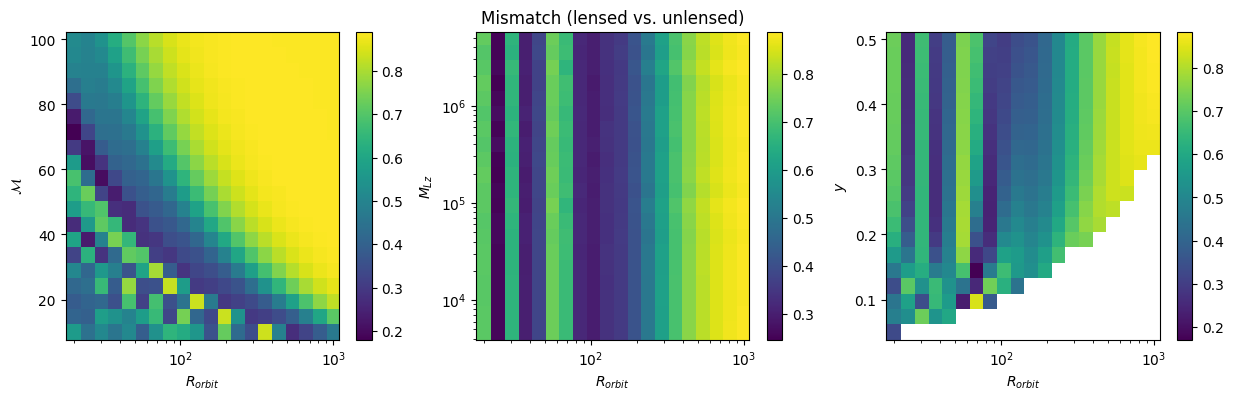

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

ax = axs[0]
im = ax.pcolormesh(R_orbit_array, Mc_array, mismatch_1)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$\cal M$')

ax = axs[1]
im = ax.pcolormesh(R_orbit_array, M_lz_array, mismatch_2)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Mismatch (lensed vs. unlensed)')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$M_{Lz}$')

ax = axs[2]
im = ax.pcolormesh(R_orbit_array, src_pos_array, mismatch_3)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$y$')

These plots don't look qualitatively different from the ones done for mismatch between unlensed and second-order lensed waveforms.